# Import Libraries

In [9]:
import numpy as np               # For handling large, multi-dimensional arrays and matrices.
import pandas as pd              # For data manipulation and analysis (used to read CSV files).
import matplotlib.pyplot as plt  # For creating visualizations like accuracy/loss graphs.
import cv2                       # OpenCV: used for computer vision and image processing.
import tensorflow as tf          # The core framework for building and training neural networks.
from PIL import Image            # Python Imaging Library: used to open and resize images.
import os 
from sklearn.model_selection import train_test_split # Helper to split data into training/testing sets.
from keras.utils import to_categorical # Converts class labels into one-hot encoded vectors.
from keras.models import Sequential, load_model # Classes to define a linear stack of layers.
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization  # The building blocks of the CNN.
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# VISUALIZING DATA DISTRIBUTION

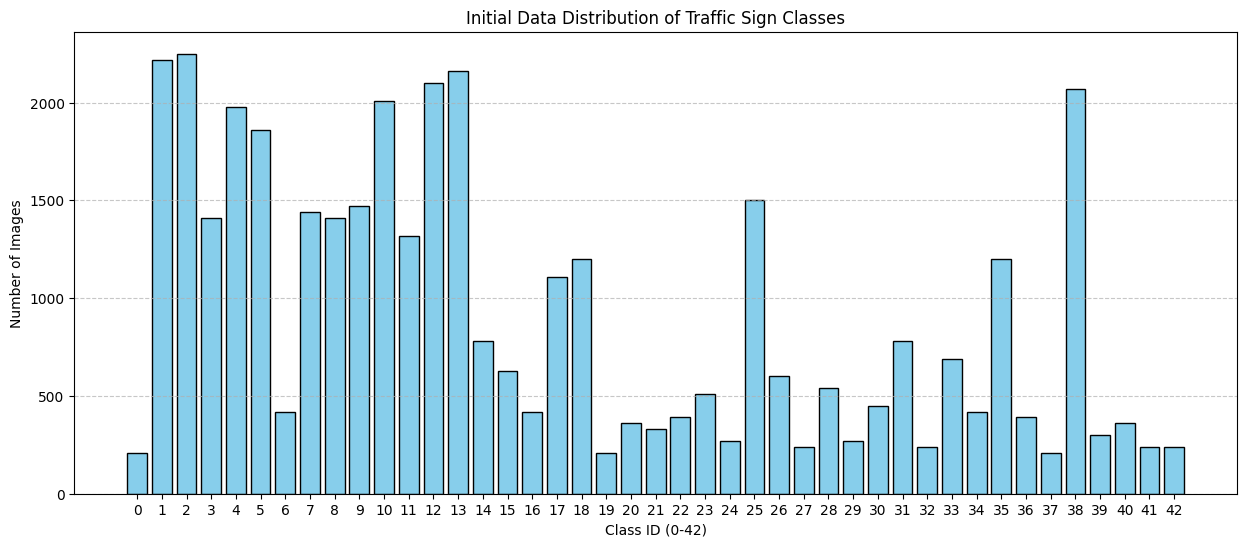

In [10]:
train_path = os.path.join(os.getcwd(), 'data', 'Train')
folders = os.listdir(train_path)

# Dictionary to store counts
class_counts = []
class_names = []

for folder in range(43):
    path = os.path.join(train_path, str(folder))
    images = os.listdir(path)
    class_counts.append(len(images))
    class_names.append(folder)

# Plotting the distribution
plt.figure(figsize=(15, 6))
plt.bar(class_names, class_counts, color='skyblue', edgecolor='black')
plt.xlabel('Class ID (0-42)')
plt.ylabel('Number of Images')
plt.title('Initial Data Distribution of Traffic Sign Classes')
plt.xticks(range(0, 43))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data Preparation and Preprocessing

In [11]:
data = []     # Empty list to store the pixel data of every image.
labels = []   # Empty list to store the category ID (0-42) for each image.
classes = 43  # The total number of unique traffic sign types in the dataset.
cur_path = os.getcwd() # Gets the current path 

In [ ]:
# Create CLAHE object once to reuse for all images (more efficient than creating it inside the loop)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# function to apply CLAHE to an image array
def apply_clahe(image_array):
    """Apply CLAHE to each RGB channel separately to fix uneven lighting."""
    channels = cv2.split(image_array)               # Split into R, G, B
    equalized = [clahe.apply(ch) for ch in channels] # Apply CLAHE per channel
    return cv2.merge(equalized)                      # Merge back together

# Loop through each class folder, read and preprocess images, and store them with their labels.
for i in range(classes):
    path = os.path.join(cur_path, 'data', 'Train', str(i))
    images = os.listdir(path)
    for a in images:
        try:
            image = Image.open(os.path.join(path, a))
            image = image.resize((64, 64)) # Resize to 64x64 pixels for uniformity and to reduce computational load.
            image = np.array(image)
            image = apply_clahe(image)   # Here we apply CLAHE to correct for uneven lighting conditions in the images.         
            data.append(image)
            labels.append(i)
        except Exception as e:
            print(e)

## Converting lists into numpy arrays

In [14]:
data = np.array(data)
labels = np.array(labels)

## Normalizing pixel values to a range of 0 to 1

In [ ]:
data = data.astype('float32') / 255.0 # Normalize pixel values to [0, 1] range for better training performance.

In [16]:
print(data.shape, labels.shape)

(39209, 64, 64, 3) (39209,)


# Save Labels & Data for future use

In [17]:
if not os.path.exists('training'):
    os.mkdir('training')

np.save('./training/data', data)
np.save('./training/target', labels)

# DATA SPLITTING & AUGMENTATION

In [ ]:
# DATA SPLIT STRATEGY:
# We split the Train folder 80/20 → X_train (80%) is used for training,
# X_test (20%) is used as validation_data during model.fit() to monitor
# overfitting and trigger callbacks (EarlyStopping, ReduceLROnPlateau).
#
# The true final evaluation is done separately on Test.csv which has path details to Test data(testing() function),
# which is completely held-out data the model never sees during training.
# This gives an unbiased measure of real-world performance.

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=0)

y_train_raw = y_train.copy()   # integer labels  e.g. [0, 2, 5, 41 ...] // changed
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)


In [19]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(43),
    y=y_train_raw
)
class_weights = dict(enumerate(weights))
 
print("\nClass weights (sample):")
for k in list(class_weights.keys())[:5]:
    print(f"  Class {k}: {class_weights[k]:.3f}")


Class weights (sample):
  Class 0: 4.316
  Class 1: 0.410
  Class 2: 0.405
  Class 3: 0.643
  Class 4: 0.462


# DATA AUGMENTATION

## Creating a generator to artificially expand the dataset

In [20]:
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    fill_mode="nearest"
)

# CNN ARCHITECTURE

In [21]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(BatchNormalization())  
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(BatchNormalization())   
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())   
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())   
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())   
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()



c:\USJ Lectures\Third_Year\SEM6\DL\DL_Assignment\Traffic_Sign_Classifier_V3\tsr_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,455,883 (9.37 MB)

 Trainable params: 2,454,987 (9.37 MB)

 Non-trainable params: 896 (3.50 KB)

# TRAINING WITH AUGMENTATION 

In [ ]:
batch_size = 32
epochs = 35  
# function for training the model with callbacks for better performance and to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                  # stops if no improvement for 5 epochs
    restore_best_weights=True    # rolls back to the best epoch automatically
)
# function to reduce learning rate when the model is stuck (plateau) to help it escape local minima and converge better
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # halves the learning rate when stuck
    patience=3,      # waits 3 epochs before reducing
    min_lr=1e-6,
    verbose=1        # prints a message when LR is reduced
)

history = model.fit(
    aug.flow(X_train, y_train, batch_size=batch_size),
    validation_data=(X_test, y_test),
    epochs=epochs,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]  # ✅ ADD: pass callbacks here
)

model.save("./training/TSR_Augmented.h5")

Epoch 1/35
981/981 ━━━━━━━━━━━━━━━━━━━━ 152s 124ms/step - accuracy: 0.5689 - loss: 1.4756 - val_accuracy: 0.8542 - val_loss: 0.5931 - learning_rate: 0.0010
Epoch 2/35
981/981 ━━━━━━━━━━━━━━━━━━━━ 126s 129ms/step - accuracy: 0.8358 - loss: 0.4747 - val_accuracy: 0.9588 - val_loss: 0.1561 - learning_rate: 0.0010
Epoch 3/35
981/981 ━━━━━━━━━━━━━━━━━━━━ 121s 123ms/step - accuracy: 0.9084 - loss: 0.2703 - val_accuracy: 0.9799 - val_loss: 0.0732 - learning_rate: 0.0010
Epoch 4/35
981/981 ━━━━━━━━━━━━━━━━━━━━ 121s 123ms/step - accuracy: 0.9354 - loss: 0.1834 - val_accuracy: 0.9843 - val_loss: 0.0555 - learning_rate: 0.0010
Epoch 5/35
981/981 ━━━━━━━━━━━━━━━━━━━━ 120s 122ms/step - accuracy: 0.9474 - loss: 0.1496 - val_accuracy: 0.9889 - val_loss: 0.0423 - learning_rate: 0.0010
Epoch 6/35
981/981 ━━━━━━━━━━━━━━━━━━━━ 130s 132ms/step - accuracy: 0.9538 - loss: 0.1343 - val_accuracy: 0.9838 - val_loss: 0.0569 - learning_rate: 0.0010
Epoch 7/35
981/981 ━━━━━━━━━━━━━━━━━━━━ 153s 156ms/step - accura

# TESTING

In [ ]:
def testing(testcsv):
    y_test_df = pd.read_csv(testcsv)
    labels = y_test_df["ClassId"].values
    imgs = y_test_df["Path"].values
    data_list = []

    for img in imgs:
        image_path = os.path.join('data', img)
        image = Image.open(image_path)
        image = image.resize((64, 64))
        image = np.array(image)
        image = apply_clahe(image)                  
        data_list.append(image)

    X_test_data = np.array(data_list)
    return X_test_data.astype('float32') / 255.0, labels

# UPDATED: Path changed to 'data/Test.csv'
X_test_final, label_actual = testing('data/Test.csv') 

Y_pred = np.argmax(model.predict(X_test_final), axis=-1)

from sklearn.metrics import accuracy_score, classification_report
print("Final Augmented Test Accuracy:", accuracy_score(label_actual, Y_pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step
Final Augmented Test Accuracy: 0.9893111638954869


# Classification Report 

In [25]:
print("\nPer-class report:")
print(classification_report(label_actual, Y_pred, digits=3))


Per-class report:
              precision    recall  f1-score   support

           0      0.822     1.000     0.902        60
           1      0.992     1.000     0.996       720
           2      0.996     0.995     0.995       750
           3      0.998     0.982     0.990       450
           4      0.998     0.992     0.995       660
           5      0.960     0.995     0.977       630
           6      1.000     0.913     0.955       150
           7      0.987     1.000     0.993       450
           8      1.000     0.951     0.975       450
           9      1.000     1.000     1.000       480
          10      1.000     0.998     0.999       660
          11      0.993     1.000     0.996       420
          12      1.000     0.988     0.994       690
          13      1.000     0.999     0.999       720
          14      1.000     1.000     1.000       270
          15      0.972     1.000     0.986       210
          16      1.000     1.000     1.000       150
        

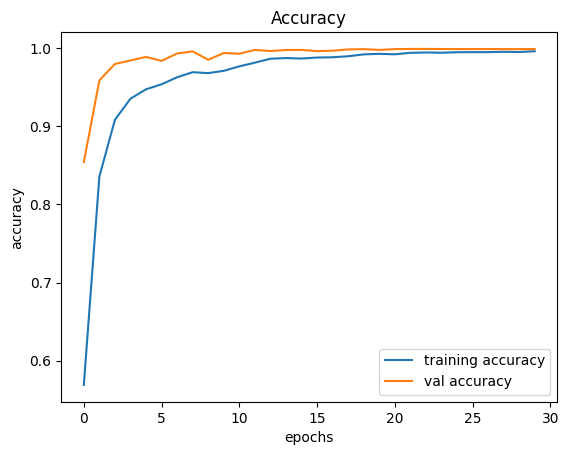

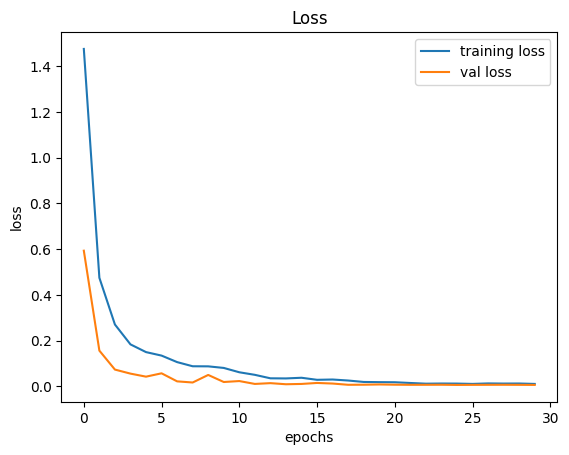

In [26]:
# --- SECTION 6: PLOTTING PERFORMANCE ---

# Accuracy plot
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

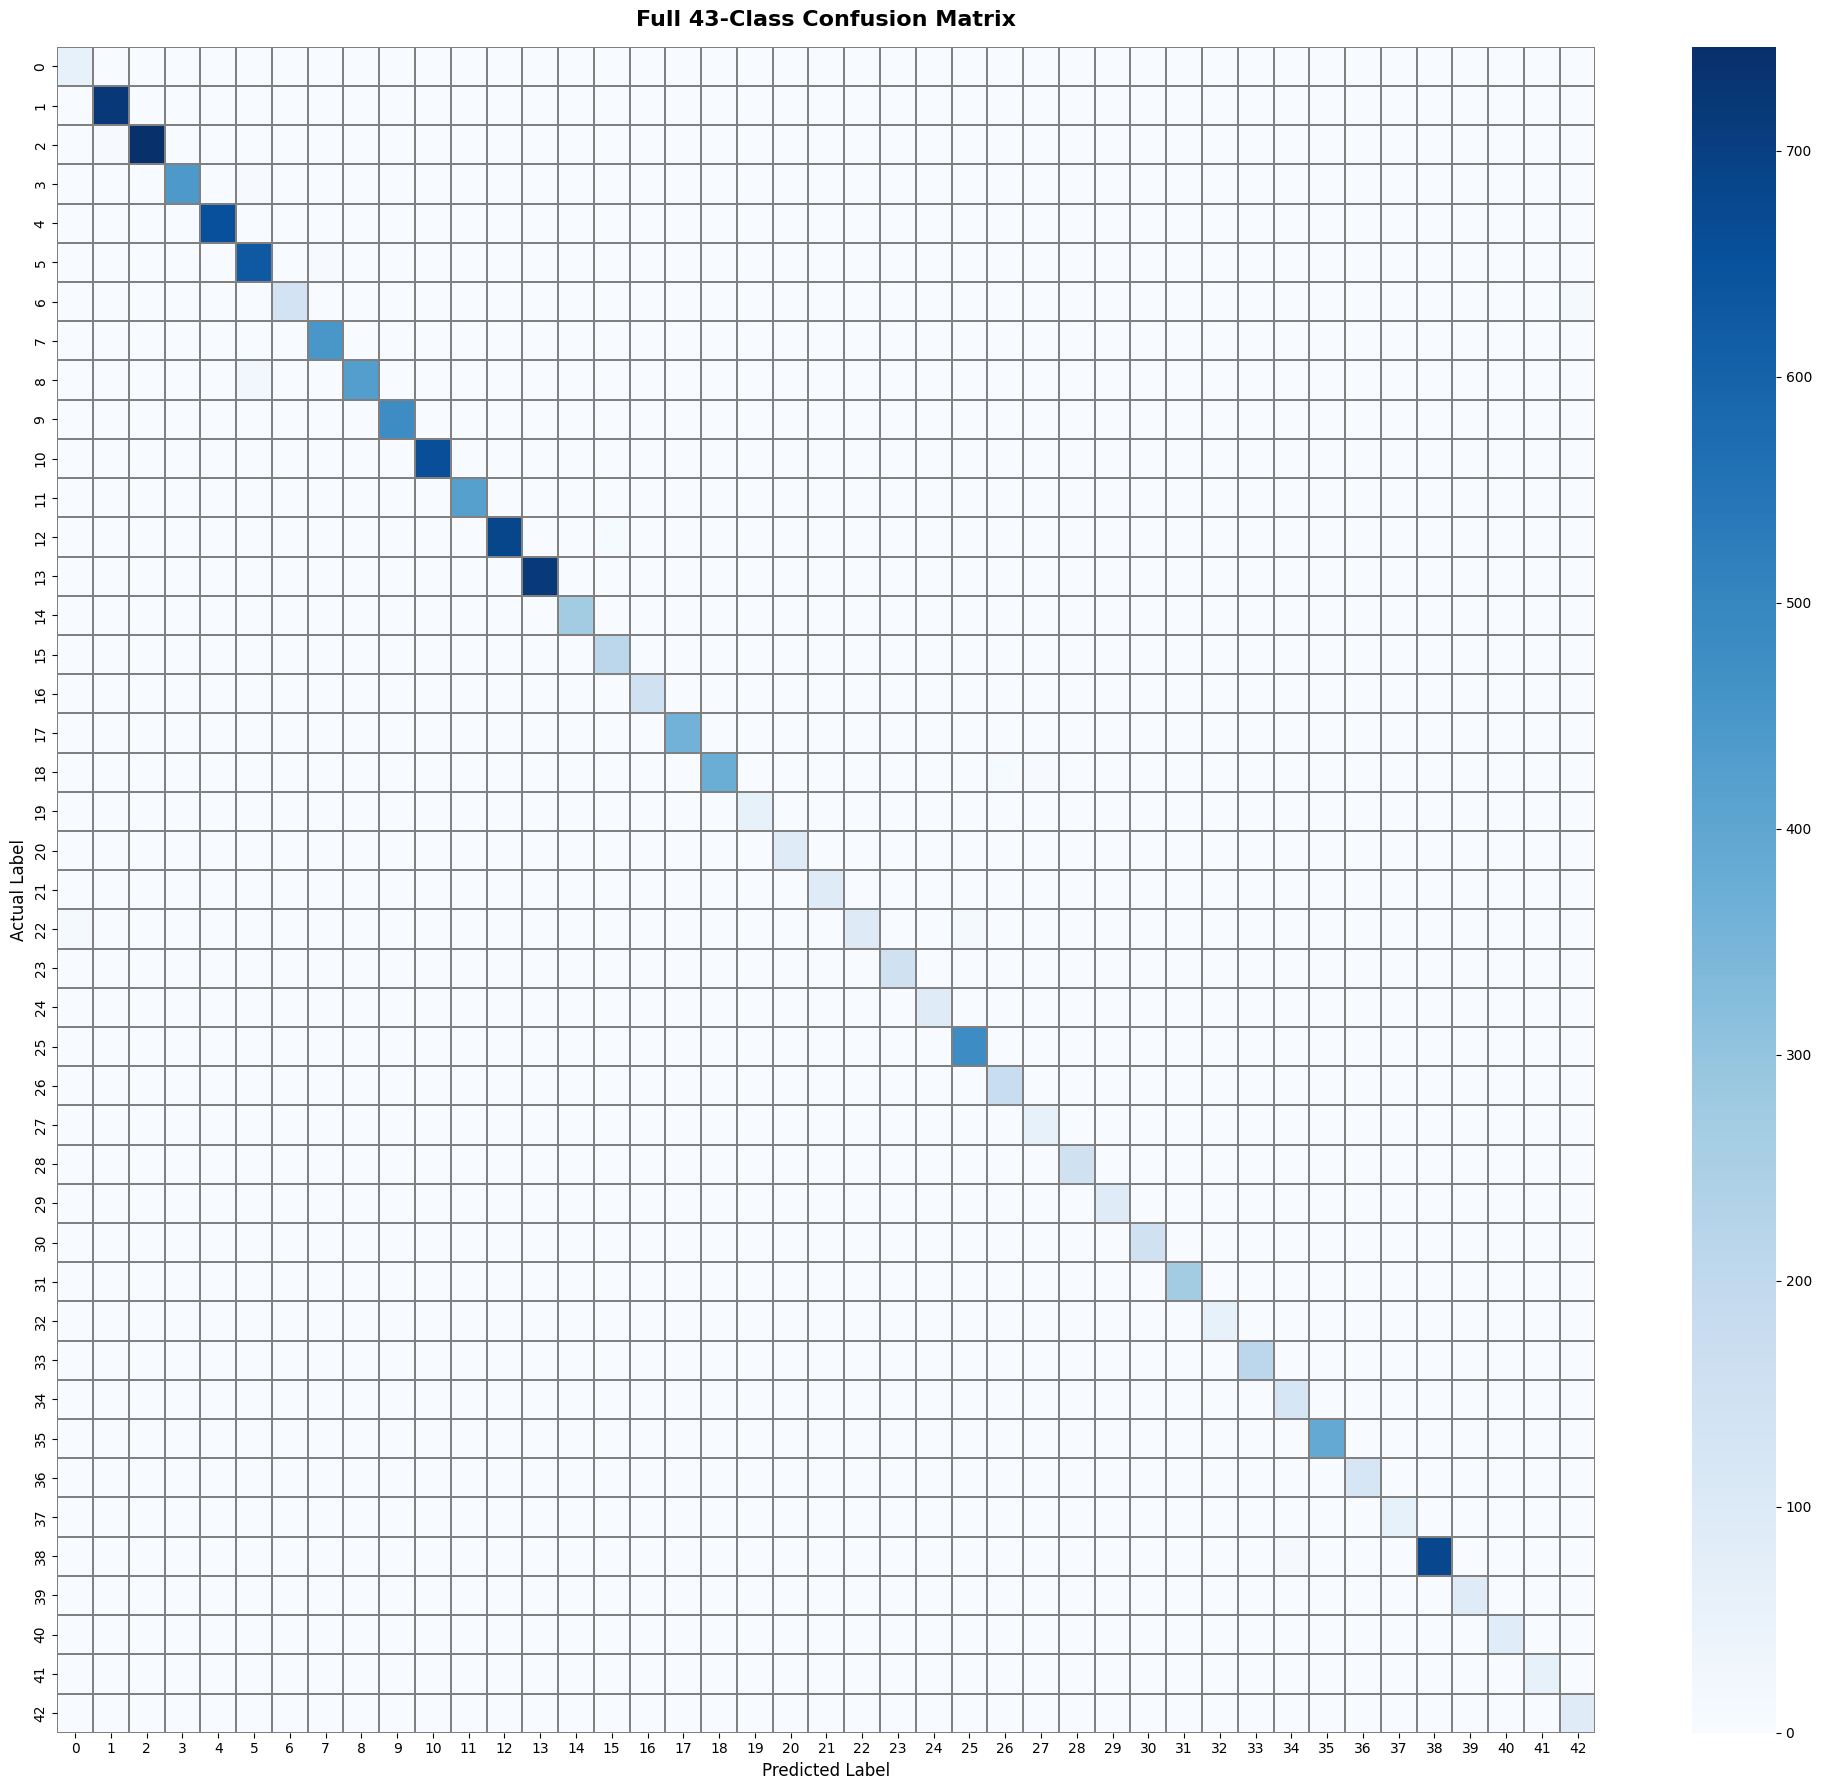

Top 10 Most Confused Pairs (Actual → Predicted):
--------------------------------------------------
  Actual:  8 (Speed limit 120          ) → Predicted:  5 (Speed limit 80           ) | 21 times
  Actual: 22 (Dangerous curve          ) → Predicted: 25 (Steep descent            ) | 14 times
  Actual:  6 (Speed limit end 80       ) → Predicted: 42 (Turn left                ) | 12 times
  Actual: 22 (Dangerous curve          ) → Predicted:  0 (Speed limit 20           ) | 12 times
  Actual: 38 (Ice/snow                 ) → Predicted: 34 (Speed limit 120 end      ) | 9 times
  Actual: 12 (Priority road            ) → Predicted: 15 (No entry                 ) | 6 times
  Actual: 18 (No entry both            ) → Predicted: 26 (Steep climb              ) | 6 times
  Actual:  3 (Speed limit 60           ) → Predicted:  5 (Speed limit 80           ) | 5 times
  Actual:  2 (Speed limit 50           ) → Predicted:  1 (Speed limit 30           ) | 4 times
  Actual: 18 (No entry both            ) 

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Map ClassId to traffic sign descriptions (GTSRB dataset)
classes_dict = {
    0: 'Speed limit 20', 1: 'Speed limit 30', 2: 'Speed limit 50', 3: 'Speed limit 60', 4: 'Speed limit 70',
    5: 'Speed limit 80', 6: 'Speed limit end 80', 7: 'Speed limit 100', 8: 'Speed limit 120', 9: 'No passing',
    10: 'No passing trucks', 11: 'Right of way', 12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No entry',
    16: 'Prohibited', 17: 'Prohibited trucks', 18: 'No entry both', 19: 'Caution', 20: 'Dangerous left', 
    21: 'Dangerous right', 22: 'Dangerous curve', 23: 'Bumpy road', 24: 'Slippery', 25: 'Steep descent',
    26: 'Steep climb', 27: 'Keep right', 28: 'Keep left', 29: 'Roundabout', 30: 'End no passing', 
    31: 'End no passing trucks', 32: 'Speed limit 80 end', 33: 'Speed limit 100 end', 34: 'Speed limit 120 end',
    35: 'Pedestrian crossing', 36: 'Children crossing', 37: 'Bicycle crossing', 38: 'Ice/snow', 39: 'Wildlife',
    40: 'End restrictions', 41: 'Turn right', 42: 'Turn left'
}

# Full 43-class confusion matrix
cm_full = confusion_matrix(label_actual, Y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm_full,
    annot=False,        # Turn off numbers — 43x43 is too dense to read
    cmap='Blues',
    linewidths=0.3,
    linecolor='gray',
    xticklabels=range(43),
    yticklabels=range(43)
)
plt.title('Full 43-Class Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Top 10 most confused pairs (more useful than staring at a dense heatmap)
print("Top 10 Most Confused Pairs (Actual → Predicted):")
print("-" * 50)
cm_copy = cm_full.copy()
np.fill_diagonal(cm_copy, 0)  # ignore correct predictions

for i in range(10):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    count = cm_copy[idx]
    if count == 0:
        break
    print(f"  Actual: {idx[0]:2d} ({classes_dict[idx[0]][:25]:25s}) → "
          f"Predicted: {idx[1]:2d} ({classes_dict[idx[1]][:25]:25s}) | {count} times")
    cm_copy[idx] = 0
